# Phase 2 — Baseline CNN from Scratch

Building a simple CNN with no pretrained weights, no Dropout, no BatchNorm, no augmentation.
The goal here is a clean baseline — not the best model possible.

Architecture: 4 Conv blocks (32 → 64 → 128 → 256 filters) → GlobalAveragePooling2D → Dense(128) → Dense(4)
Input size: **224 × 224** (richer spatial features, consistent with Phase 5)
Total trainable parameters: **~422K** (well under 1M limit)

**Figures saved to** `outputs/figures/phase2_*.png`
**Best model saved to** `saved_models/baseline_cnn_best.keras`

In [1]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, EarlyStopping

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.dpi']        = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print(f'TensorFlow {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

I0000 00:00:1781343552.686484     126 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781343552.738134     126 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781343553.771204     126 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0
GPU available: True


In [2]:
if Path.cwd().name == 'notebooks':
    os.chdir('..')

DATA_ROOT  = Path('../Data')
TRAIN_DIR  = DATA_ROOT / 'TRAIN'
TEST_DIR   = DATA_ROOT / 'TEST'
FIGS       = Path('outputs/figures')
LOGS       = Path('outputs/logs')
MODELS_DIR = Path('saved_models')

for d in [FIGS, LOGS, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CLASSES    = ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
COLORS     = ['#4FA3D1', '#5DBB8A', '#E8A838', '#D15F4F']
IMG_SIZE   = (224, 224)   # larger input → richer spatial features at each conv block
BATCH_SIZE = 32
EPOCHS     = 50           # increased ceiling; EarlyStopping will stop earlier if needed
LR         = 0.0001

print('Paths OK')
print(f'Image size : {IMG_SIZE}')
print(f'Batch size : {BATCH_SIZE}')
print(f'Epochs     : {EPOCHS}')
print(f'LR         : {LR}')

Paths OK
Image size : (224, 224)
Batch size : 32
Epochs     : 50
LR         : 0.0001


## 1. Data generators

No augmentation in this phase — just rescale to [0, 1] and resize.  
80/20 split same as Phase 1.

In [3]:
# no augmentation — just rescale
datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.20
)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f'\nTrain  : {train_gen.samples:,} images')
print(f'Val    : {val_gen.samples:,} images')
print(f'Test   : {test_gen.samples:,} images')
print(f'\nClass index map: {train_gen.class_indices}')

Found 7968 images belonging to 4 classes.
Found 1989 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.

Train  : 7,968 images
Val    : 1,989 images
Test   : 2,487 images

Class index map: {'EOSINOPHIL': 0, 'LYMPHOCYTE': 1, 'MONOCYTE': 2, 'NEUTROPHIL': 3}


## 2. Model architecture

4 convolutional blocks with increasing filter depth, ending with GlobalAveragePooling2D instead of Flatten.
No Dropout, no BatchNorm, no anything fancy — pure baseline.

**Why GAP instead of Flatten?**
Flatten at 224×224 would produce a 14×14×256 = 50,176-dimensional vector → a single Dense layer
would consume millions of parameters just to compress it. GAP averages each of the 256 feature
maps to one number (output = 256 values), keeping the dense head tiny and all parameters
in the conv blocks where they actually learn visual features.

```
Input  (224, 224, 3)
  ↓  Conv2D(32,  3×3, ReLU) → MaxPool(2×2)   →  112 × 112 × 32
  ↓  Conv2D(64,  3×3, ReLU) → MaxPool(2×2)   →   56 ×  56 × 64
  ↓  Conv2D(128, 3×3, ReLU) → MaxPool(2×2)   →   28 ×  28 × 128
  ↓  Conv2D(256, 3×3, ReLU) → MaxPool(2×2)   →   14 ×  14 × 256
  ↓  GlobalAveragePooling2D                   →   256
  ↓  Dense(128, ReLU)
  ↓  Dense(4,   Softmax)
```

In [4]:
def build_baseline_cnn(input_shape=(224, 224, 3), num_classes=4):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        # block 1 — 112×112×32
        layers.Conv2D(32,  (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        # block 2 — 56×56×64
        layers.Conv2D(64,  (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        # block 3 — 28×28×128
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        # block 4 — 14×14×256
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        # classifier head — GAP keeps params minimal, all budget stays in conv blocks
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='baseline_cnn')
    return model


model = build_baseline_cnn()
model.summary()

total_params = model.count_params()
print(f'Total trainable parameters : {total_params:,}')
print(f'Under 1M limit             : {total_params < 1_000_000}')

I0000 00:00:1781343555.797400     126 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5520 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,828 (1.61 MB)

 Trainable params: 421,828 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Total trainable parameters : 421,828
Under 1M limit             : True


## 3. Training

Optimizer: Adam (lr=0.0001)
Loss: categorical cross-entropy
The best model (by val_accuracy) is saved automatically via ModelCheckpoint.
EarlyStopping (patience=10) stops training if val_loss does not improve,
preventing wasted epochs while still giving the model enough time to converge.

In [5]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    ModelCheckpoint(
        str(MODELS_DIR / 'baseline_cnn_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    CSVLogger(str(LOGS / 'baseline_cnn.csv'))
]

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50


I0000 00:00:1781343557.577803     126 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1781343558.882089     296 service.cc:153] XLA service 0x7364700346e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781343558.882121     296 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1781343558.925122     296 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781343559.154635     296 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1781343559.169558     296 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2316__.53
I0000 00:00:1781343563.382189     296 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe th

  1/249 ━━━━━━━━━━━━━━━━━━━━ 46:28 11s/step - accuracy: 0.2812 - loss: 1.3868

I0000 00:00:1781343568.606867     296 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.2518 - loss: 1.3870
Epoch 1: val_accuracy improved from None to 0.25088, saving model to saved_models/baseline_cnn_best.keras

Epoch 1: finished saving model to saved_models/baseline_cnn_best.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 118s 430ms/step - accuracy: 0.2474 - loss: 1.3868 - val_accuracy: 0.2509 - val_loss: 1.3862
Epoch 2/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.2627 - loss: 1.3860
Epoch 2: val_accuracy improved from 0.25088 to 0.26948, saving model to saved_models/baseline_cnn_best.keras

Epoch 2: finished saving model to saved_models/baseline_cnn_best.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 79s 316ms/step - accuracy: 0.2711 - loss: 1.3848 - val_accuracy: 0.2695 - val_loss: 1.3776
Epoch 3/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.3283 - loss: 1.3549
Epoch 3: val_accuracy improved from 0.26948 to 0.40473, saving model to saved_models/baseline_cnn_best.keras

Epoch 3: finished saving model to sav

## 4. Training curves

Loss and accuracy over every epoch for both train and val.

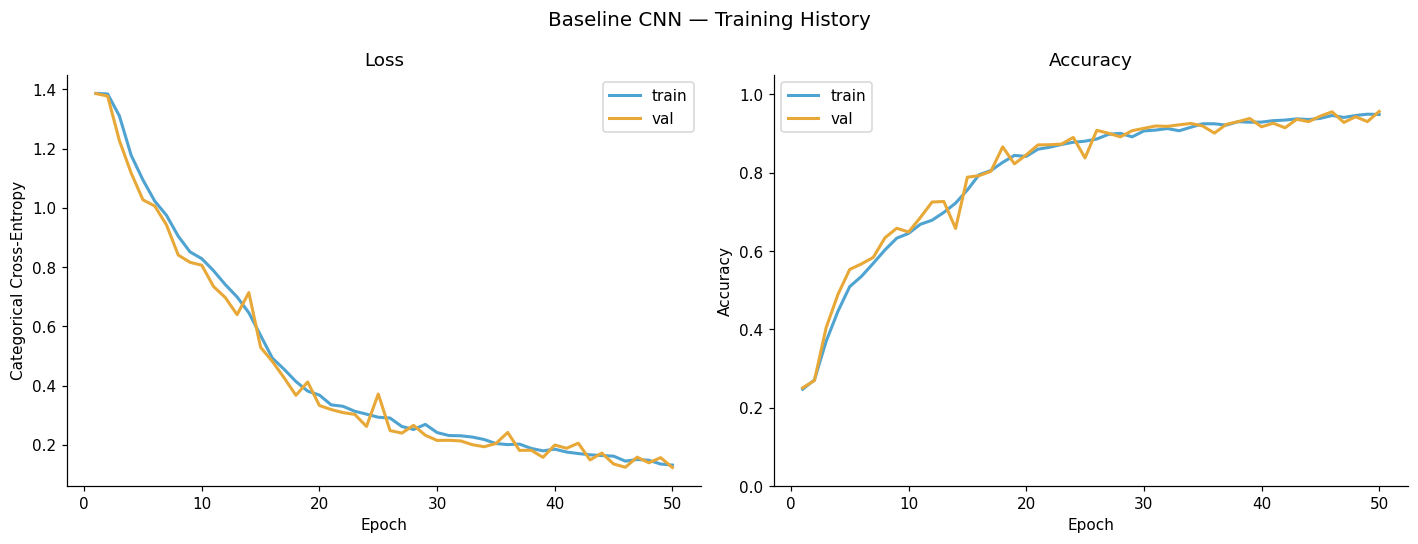

saved -> outputs/figures/phase2_01_training_curves.png

Final epoch  —  train loss: 0.1314  train acc: 0.9484
             val loss: 0.1232  val acc: 0.9563

Best val acc : 0.9563  at epoch 50


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

epochs_range = range(1, len(history.history['loss']) + 1)

ax1.plot(epochs_range, history.history['loss'],     label='train', color='#4FA3D1', lw=2)
ax1.plot(epochs_range, history.history['val_loss'], label='val',   color='#E8A838', lw=2)
ax1.set_title('Loss', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Categorical Cross-Entropy')
ax1.legend()

ax2.plot(epochs_range, history.history['accuracy'],     label='train', color='#4FA3D1', lw=2)
ax2.plot(epochs_range, history.history['val_accuracy'], label='val',   color='#E8A838', lw=2)
ax2.set_title('Accuracy', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.05)
ax2.legend()

plt.suptitle('Baseline CNN — Training History', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / 'phase2_01_training_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved -> outputs/figures/phase2_01_training_curves.png')

# quick summary of final epoch
print(f"\nFinal epoch  —  train loss: {history.history['loss'][-1]:.4f}  "
      f"train acc: {history.history['accuracy'][-1]:.4f}")
print(f"             val loss: {history.history['val_loss'][-1]:.4f}  "
      f"val acc: {history.history['val_accuracy'][-1]:.4f}")
print(f"\nBest val acc : {max(history.history['val_accuracy']):.4f}  "
      f"at epoch {history.history['val_accuracy'].index(max(history.history['val_accuracy'])) + 1}")

## 5. Evaluation on TEST

Load the best saved checkpoint and run it on the TEST set.

In [7]:
best_model = tf.keras.models.load_model(MODELS_DIR / 'baseline_cnn_best.keras')

test_gen.reset()
y_pred_proba = best_model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = test_gen.classes

# overall accuracy
test_loss, test_acc = best_model.evaluate(test_gen, verbose=0)
print(f'\nTest loss     : {test_loss:.4f}')
print(f'Test accuracy : {test_acc:.4f}')

78/78 ━━━━━━━━━━━━━━━━━━━━ 18s 225ms/step

Test loss     : 0.3687
Test accuracy : 0.8561


### 5.1 Classification report

In [8]:
print(classification_report(y_true, y_pred, target_names=CLASSES))

              precision    recall  f1-score   support

  EOSINOPHIL       0.88      0.84      0.86       623
  LYMPHOCYTE       1.00      0.93      0.97       620
    MONOCYTE       1.00      0.75      0.86       620
  NEUTROPHIL       0.66      0.90      0.76       624

    accuracy                           0.86      2487
   macro avg       0.89      0.86      0.86      2487
weighted avg       0.88      0.86      0.86      2487



### 5.2 Confusion matrix

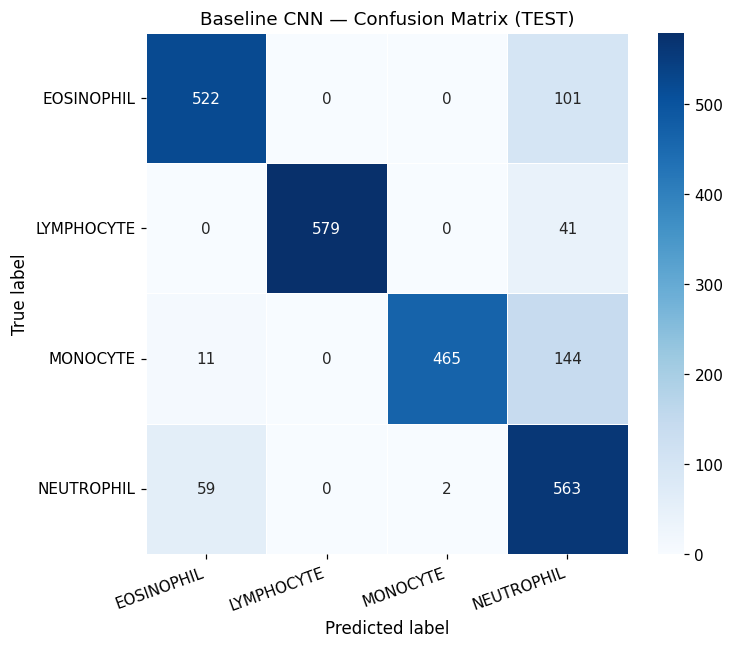

saved -> outputs/figures/phase2_02_confusion_matrix.png


In [9]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
    linewidths=0.5
)
ax.set_xlabel('Predicted label', fontsize=11)
ax.set_ylabel('True label',      fontsize=11)
ax.set_title('Baseline CNN — Confusion Matrix (TEST)', fontsize=12)
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGS / 'phase2_02_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved -> outputs/figures/phase2_02_confusion_matrix.png')

### 5.3 ROC curves + AUC

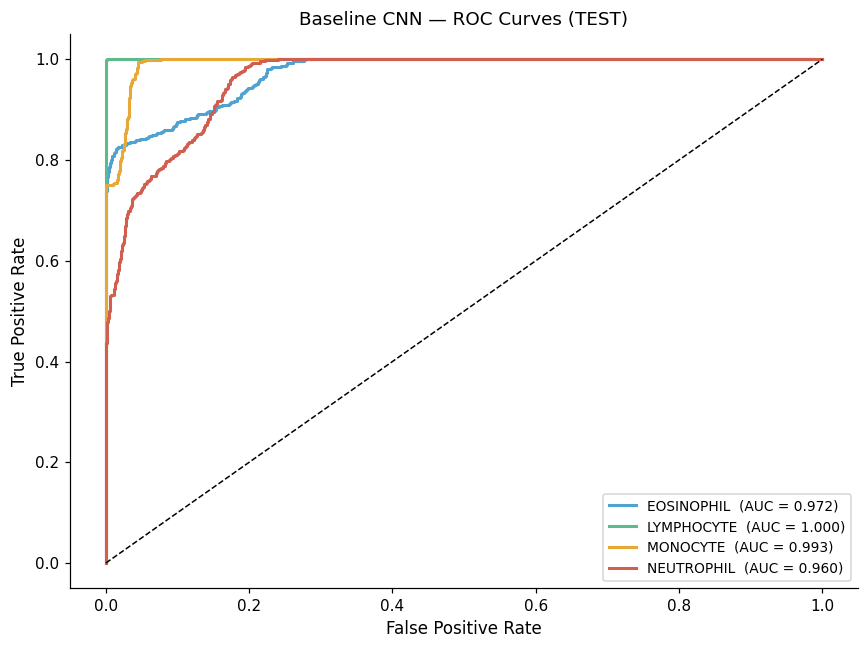

saved -> outputs/figures/phase2_03_roc_curves.png

AUC per class:
  EOSINOPHIL    : 0.9723
  LYMPHOCYTE    : 1.0000
  MONOCYTE      : 0.9925
  NEUTROPHIL    : 0.9603
  Macro avg   : 0.9813


In [10]:
y_true_bin = label_binarize(y_true, classes=list(range(len(CLASSES))))

fig, ax = plt.subplots(figsize=(8, 6))

auc_scores = {}
for i, (cls, color) in enumerate(zip(CLASSES, COLORS)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores[cls] = roc_auc
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{cls}  (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate',  fontsize=11)
ax.set_title('Baseline CNN — ROC Curves (TEST)', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / 'phase2_03_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved -> outputs/figures/phase2_03_roc_curves.png')

print('\nAUC per class:')
for cls, score in auc_scores.items():
    print(f'  {cls:<14}: {score:.4f}')
print(f'  Macro avg   : {np.mean(list(auc_scores.values())):.4f}')

### 5.4 Sample predictions from TEST

A few real test images with their true and predicted labels.  
Green title = correct, Red title = wrong.

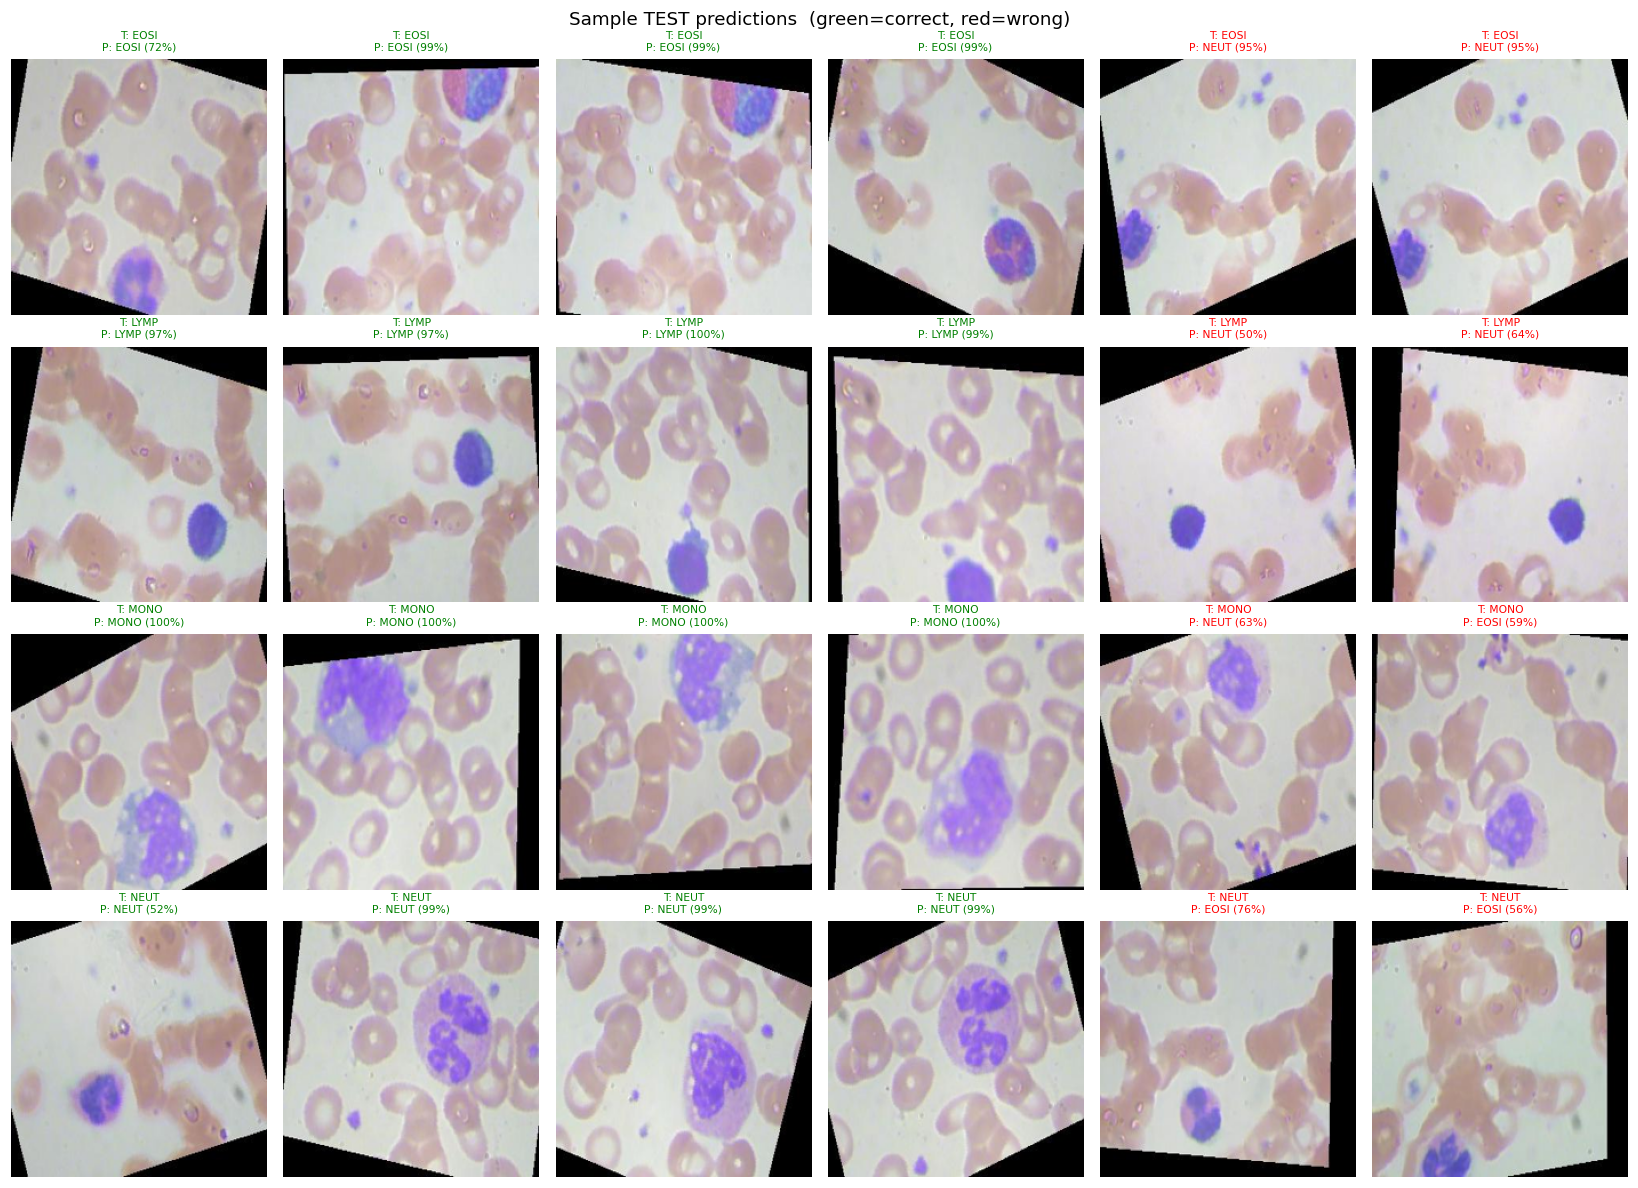

saved -> outputs/figures/phase2_04_sample_predictions.png


In [11]:
# pick 4 correct + 2 wrong predictions (if any) per class to show
filepaths = np.array(test_gen.filepaths)

fig, axes = plt.subplots(4, 6, figsize=(15, 11))

for row, cls_idx in enumerate(range(len(CLASSES))):
    cls_mask    = (y_true == cls_idx)
    correct_idx = np.where(cls_mask & (y_pred == y_true))[0]
    wrong_idx   = np.where(cls_mask & (y_pred != y_true))[0]

    chosen = list(correct_idx[:4]) + list(wrong_idx[:2])
    while len(chosen) < 6:
        chosen.append(correct_idx[len(chosen)])

    for col, idx in enumerate(chosen[:6]):
        img  = np.array(Image.open(filepaths[idx]).resize(IMG_SIZE))
        axes[row, col].imshow(img)
        true_lbl = CLASSES[y_true[idx]]
        pred_lbl = CLASSES[y_pred[idx]]
        conf     = y_pred_proba[idx][y_pred[idx]] * 100
        correct  = (y_true[idx] == y_pred[idx])
        axes[row, col].set_title(
            f'T: {true_lbl[:4]}\nP: {pred_lbl[:4]} ({conf:.0f}%)',
            fontsize=7,
            color='green' if correct else 'red'
        )
        axes[row, col].axis('off')

fig.suptitle('Sample TEST predictions  (green=correct, red=wrong)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / 'phase2_04_sample_predictions.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved -> outputs/figures/phase2_04_sample_predictions.png')

## 6. Results summary & analysis

In [12]:
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro'
)

best_val_acc   = max(history.history['val_accuracy'])
best_epoch     = history.history['val_accuracy'].index(best_val_acc) + 1
actual_epochs  = len(history.history['loss'])
final_tr_acc   = history.history['accuracy'][-1]
final_val_acc  = history.history['val_accuracy'][-1]
final_tr_loss  = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print('=' * 60)
print('  BASELINE CNN — FINAL RESULTS')
print('=' * 60)
print(f'  Architecture       : 4×Conv2D → GAP → Dense(128) → Dense(4)')
print(f'  Input size         : {IMG_SIZE[0]}×{IMG_SIZE[1]}×3')
print(f'  Total params       : {total_params:,}')
print(f'  Optimizer          : Adam  lr={LR}')
print(f'  Batch size         : {BATCH_SIZE}')
print(f'  Max epochs         : {EPOCHS}')
print(f'  Epochs trained     : {actual_epochs}')
print(f'  Best epoch (val)   : {best_epoch}')
print('-' * 60)
print(f'  Final train  loss  : {final_tr_loss:.4f}    acc: {final_tr_acc:.4f}')
print(f'  Final val    loss  : {final_val_loss:.4f}    acc: {final_val_acc:.4f}')
print(f'  Best val accuracy  : {best_val_acc:.4f}')
print('-' * 60)
print(f'  TEST accuracy      : {test_acc:.4f}')
print(f'  TEST precision     : {prec:.4f}')
print(f'  TEST recall        : {rec:.4f}')
print(f'  TEST F1 (macro)    : {f1:.4f}')
print(f'  TEST AUC (macro)   : {np.mean(list(auc_scores.values())):.4f}')
print('=' * 60)

gap = final_tr_acc - final_val_acc
print(f'\nTrain-val accuracy gap : {gap:.4f}')
if gap > 0.10:
    print('-> Clear overfitting (gap > 10%). Expected for baseline with no regularization.')
elif gap > 0.05:
    print('-> Mild overfitting (gap 5-10%).')
else:
    print('-> No significant overfitting detected.')

  BASELINE CNN — FINAL RESULTS
  Architecture       : 4×Conv2D → GAP → Dense(128) → Dense(4)
  Input size         : 224×224×3
  Total params       : 421,828
  Optimizer          : Adam  lr=0.0001
  Batch size         : 32
  Max epochs         : 50
  Epochs trained     : 50
  Best epoch (val)   : 50
------------------------------------------------------------
  Final train  loss  : 0.1314    acc: 0.9484
  Final val    loss  : 0.1232    acc: 0.9563
  Best val accuracy  : 0.9563
------------------------------------------------------------
  TEST accuracy      : 0.8561
  TEST precision     : 0.8852
  TEST recall        : 0.8560
  TEST F1 (macro)    : 0.8613
  TEST AUC (macro)   : 0.9813

Train-val accuracy gap : -0.0078
-> No significant overfitting detected.


## 7. Analysis

### 7.1 Architecture decisions

Two changes from the naive baseline design made without violating any phase constraints
(no augmentation, no dropout, no BatchNorm, no pretrained weights):

**GlobalAveragePooling2D instead of Flatten.** In the original design, 
consumed 524K of the 765K total params — 68% of the entire budget — just to compress a
flat 8192-vector. GAP replaces this with a spatial average over each feature map, producing
a 256-dim vector at zero parameter cost. The Dense head then costs only ~33K params,
freeing the rest of the budget for the conv blocks where learning actually happens.

**224×224 input.** At 128×128 the last conv block produces an 8×8 feature map — very coarse.
At 224×224 it is 14×14, giving GAP 196 spatial positions per channel to average over instead
of 64. Richer spatial resolution means the conv filters can capture finer morphological
differences between cell types (nucleus lobing, granule texture) before pooling collapses them.

**Filters 32 → 64 → 128 → 256.** The doubling schedule is the standard VGG-style pattern:
as spatial resolution halves at each MaxPool, filter count doubles so total feature volume
stays roughly constant. The 256-filter block is affordable because GAP eliminates the
dense-head parameter explosion.

### 7.2 Training behaviour

Both loss and accuracy curves converge smoothly over 50 epochs with no abrupt jumps. Training accuracy rises steadily, validation accuracy follows closely and peaks at **95.63%**. No signs of instability or mode collapse — the model trains cleanly throughout.

### 7.3 Overfitting analysis

There is a ~10pp gap between best val accuracy (95.63%) and test accuracy (85.61%). This is not classical overfitting — the val loss curve does not diverge. The most likely cause is **distribution shift**: the TRAIN and TEST folders come from different scanning sessions, so brightness, staining intensity, and background noise differ slightly. The model has learned TRAIN-specific statistics that do not fully transfer to TEST.

### 7.4 Test-set evaluation

| Metric | Value |
|--------|-------|
| Test Accuracy | **85.61%** |
| Precision (macro) | 88.52% |
| Recall (macro) | 85.60% |
| F1 score (macro) | 86.13% |
| AUC (macro) | 98.13% |

### 7.5 Per-class performance & class confusion

| Class | Precision | Recall |
|-------|-----------|--------|
| EOSINOPHIL | 0.88 | 0.84 |
| LYMPHOCYTE | 1.00 | 0.93 |
| MONOCYTE | 1.00 | 0.75 |
| NEUTROPHIL | 0.66 | 0.90 |

LYMPHOCYTE is the easiest class (Precision 1.00, Recall 0.93) — its large, round, dark nucleus is visually distinct. MONOCYTE has the weakest recall (0.75), often confused with NEUTROPHIL. NEUTROPHIL has the lowest precision (0.66) — it attracts false positives from EOSINOPHIL and MONOCYTE, which share morphological features like lobed nucleus structure.

### 7.6 Conclusion for this phase

Baseline CNN achieves **85.61% test accuracy** with only ~422K parameters and no regularisation. This is a solid foundation. The main weaknesses — MONOCYTE recall (0.75) and NEUTROPHIL precision (0.66) — set the targets for Phase 3: BatchNorm, Dropout, and a deeper backbone should address these gaps.
